In [51]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd
import cme.utils.common_utils as cu

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
import cme.simulators.diffusion_random_walk as drw

sns.set_context("paper", font_scale=2.5)
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [52]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 3, 0.1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")
mv_arr = cu.get_conf_limits(n_states)

In [53]:
add_scale, mul_scale = 0,1

In [54]:
m_mu, m_sigma, T = npx.asarray([[2]]), npx.asarray([[3]]), 100
q_mu, q_sigma, T = npx.asarray([[2]]), npx.asarray([[3]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [55]:
theta, alpha, tau = 0.9, 1.5, 0.01

mu, sigma_coef = np.asarray([2]), np.asarray([1])

n_states = drw._get_n_states(alpha, theta, tau, sigma_coef)
discrete_transition_matrix = drw.get_transition_matrix(alpha, tau, sigma_coef[0], mu, process="Wiener", n_states=n_states).round(decimals=2)
discrete_transition_matrix.shape

(11, 11)

In [56]:
sns.color_palette("Blues")[1:]

[(0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
 (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
 (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
 (0.16696655132641292, 0.48069204152249134, 0.7291503267973857),
 (0.044059976931949255, 0.3338869665513264, 0.6244521337946944)]

Text(0.5, 1.0, 'Discrete Time')

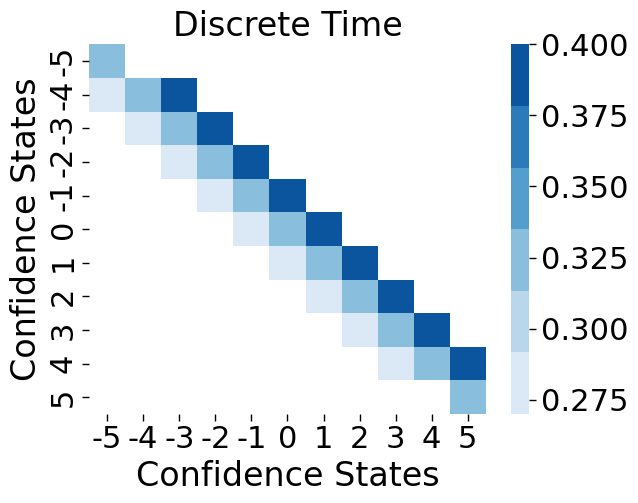

In [59]:
ax = sns.heatmap(np.where(discrete_transition_matrix.squeeze()==0,np.nan,discrete_transition_matrix.squeeze()) ,
    cmap = sns.color_palette("Blues"), xticklabels=mv_arr, yticklabels=mv_arr)
ax.set_xlabel("Confidence States")
ax.set_ylabel("Confidence States")
ax.set_title("Discrete Time")

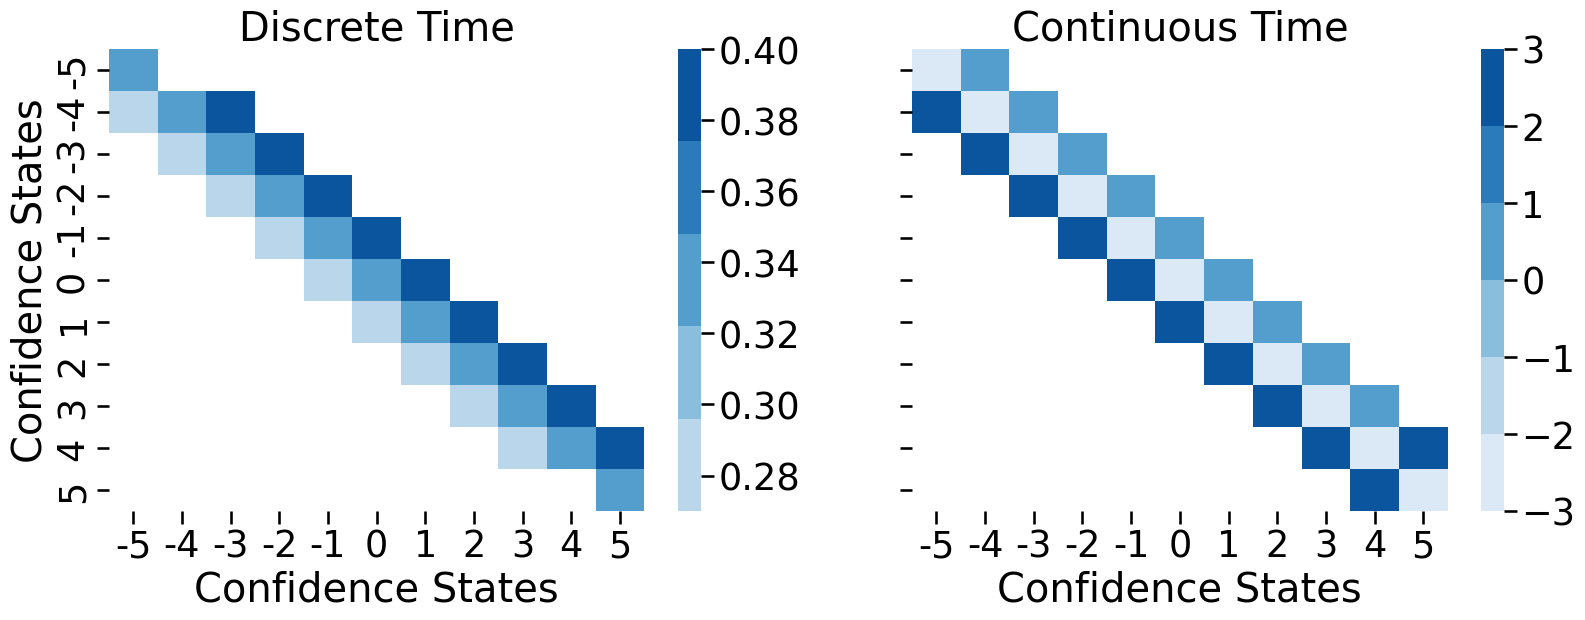

In [58]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[0].set_title("Discrete Time")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues"), ax=axs[1], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[1].set_title("Continuous Time")
    axs[0].set_xlabel("Confidence States")
    axs[1].set_xlabel("Confidence States")
    axs[0].set_ylabel("Confidence States")


<Axes: >

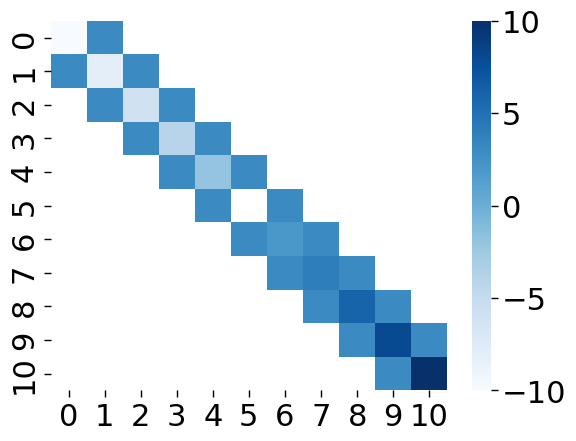

In [8]:
intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = "Blues")

In [9]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Uniform")
phi_0_markov, phi_0_quantum

(Array([[[[0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909]]]], dtype=float64),
 Array([[[[0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134]]]], dtype=float64))

In [10]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,10/delta,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,10/delta,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [11]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-5,Upper,0.0,-0.0035712072261840705,0.008071453351321464
1,-4,Upper,0.0,-0.01913753854206159,0.01610158527178253
2,-3,Upper,0.0,-0.05658336825334997,0.008030131920461089
3,-2,Upper,0.0,-0.09591682287722672,-0.04298638172311632
4,-1,Upper,0.0,-0.07618714261251247,-0.11576005965555033
...,...,...,...,...,...
32665,1,Lower,98.9,0.06775900226115003,-0.15666005321315338
32666,2,Lower,98.9,-0.028458162605025452,0.06691851776678541
32667,3,Lower,98.9,0.015142994110268312,-0.012430121789475102
32668,4,Lower,98.9,-0.008455387662360795,-0.0067928670657887175


In [12]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [13]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

In [14]:
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma_coef[0], mu,samples = 50, process="Wiener",njobs=1, scale_steps_to_boundary=False)
np.asarray(RT_arr)

array([0.66, 0.18, 0.22, 0.35, 0.08, 0.39, 0.32, 0.37, 0.25, 0.12, 0.2 ,
       0.6 , 0.34, 0.09, 0.54, 0.18, 0.18, 0.6 , 0.3 , 0.22, 0.39, 0.32,
       0.08, 0.1 , 0.36, 0.46, 0.29, 0.61, 0.19, 0.81, 0.18, 0.34, 0.29,
       0.14, 0.08, 0.44, 0.52, 0.29, 0.04, 0.13, 0.13, 0.34, 0.03, 0.07,
       0.6 , 0.29, 0.29, 0.19, 0.29, 0.66])

In [15]:
df_t = pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time").assign(time = lambda df: df.time * tau)
df_t

,time,steps
0,0.00,-2
1,0.01,-3
2,0.02,-3
3,0.03,-3
4,0.04,-2
...,...,...
62,0.62,3
63,0.63,2
64,0.64,3
65,0.65,4


In [16]:
df_markov_plot.query("time <= 20 and prior=='Uniform'")

,states,prior,time,value
11,-5,Uniform,0.0,0.090909
12,-4,Uniform,0.0,0.090909
13,-3,Uniform,0.0,0.090909
14,-2,Uniform,0.0,0.090909
15,-1,Uniform,0.0,0.090909
...,...,...,...,...
6617,1,Uniform,20.0,0.003840
6618,2,Uniform,20.0,0.019200
6619,3,Uniform,20.0,0.096000
6620,4,Uniform,20.0,0.480000


<Axes: xlabel='time', ylabel='states'>

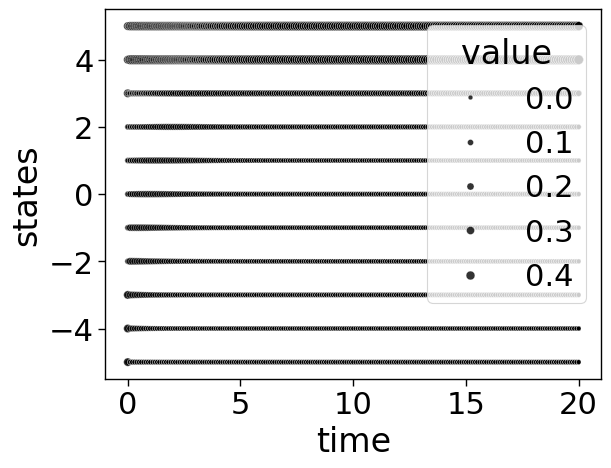

In [17]:
sns.scatterplot(df_markov_plot
                    .query("time <= 20"),
                    alpha=0.8, 
    x="time", y="states",size="value", color="Black")

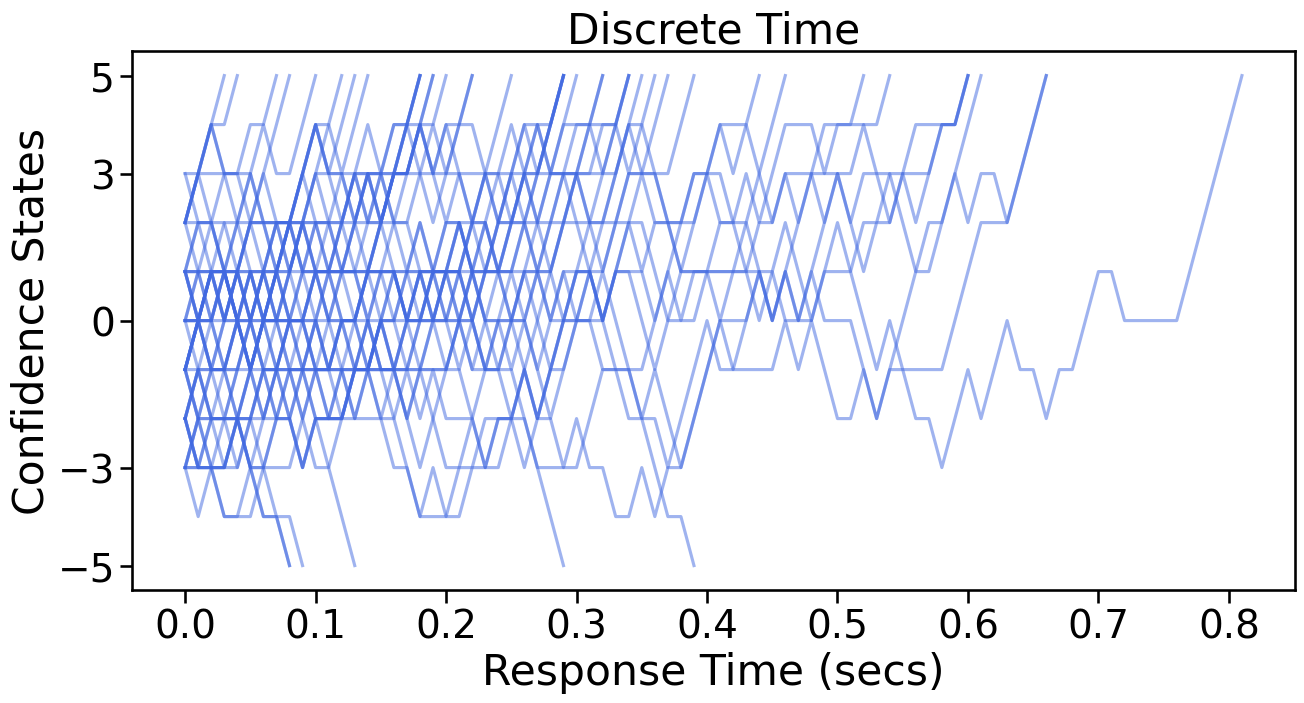

In [60]:
with sns.plotting_context("talk", font_scale=1.7):
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps")
        f.set_ylabel("Confidence States")
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time")
f.figure.set_size_inches(15,7)
f.set_yticks([-5,-3,0,3,5])

/tmp/ipykernel_3148482/242141150.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



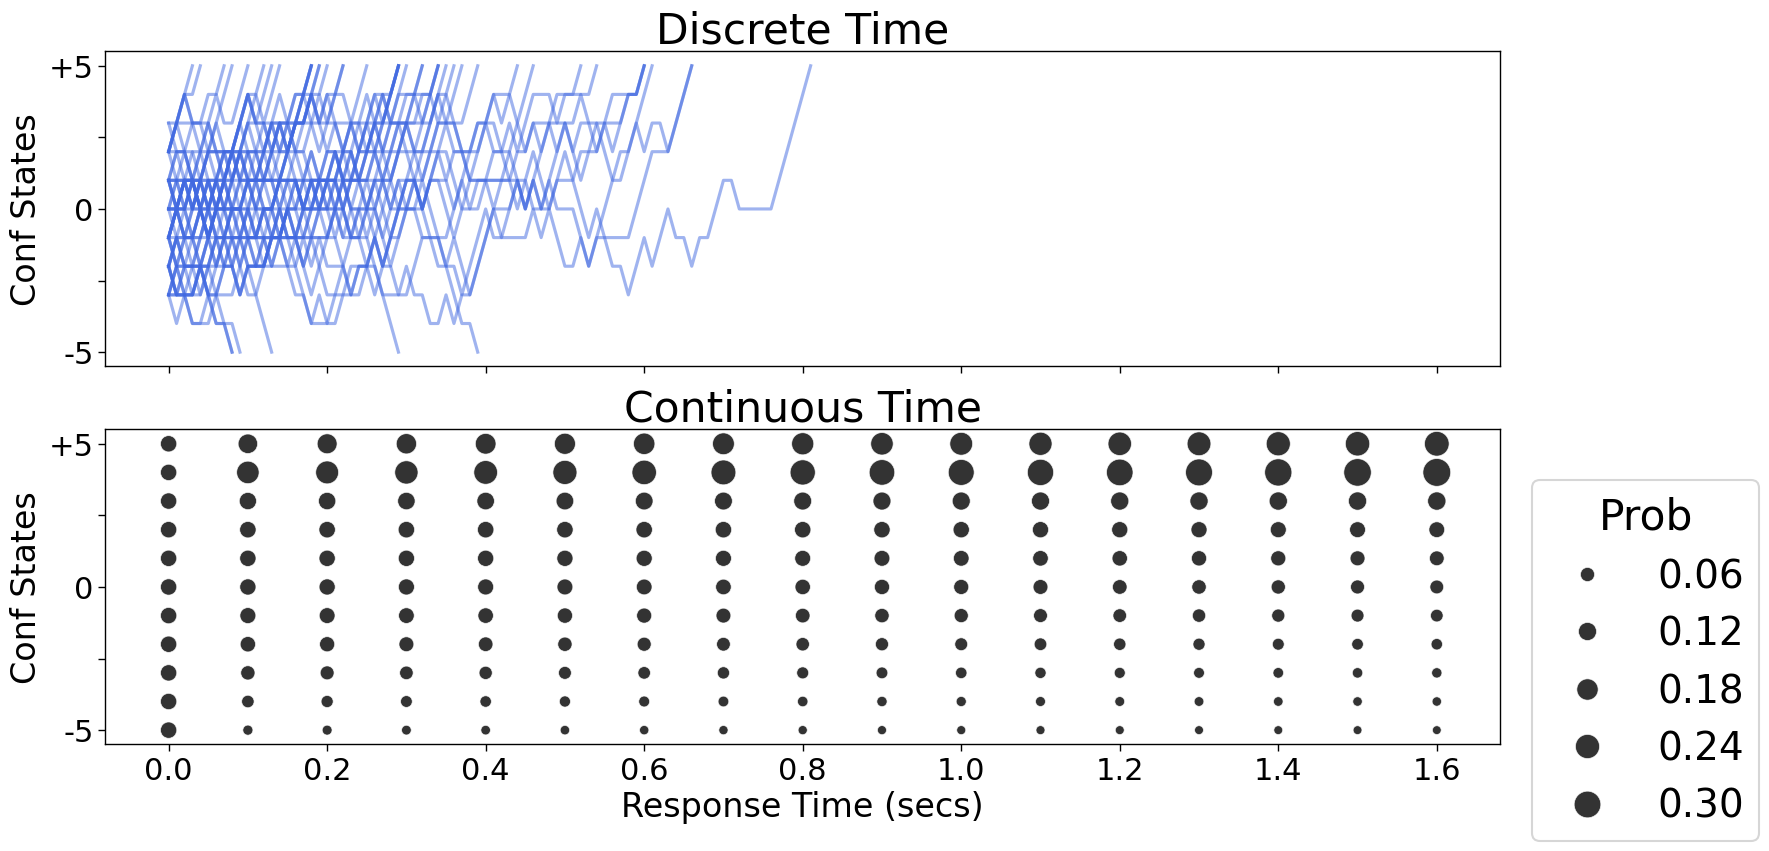

In [18]:
fig, axs = plt.subplots(2,1, figsize=(18,9), sharey=True, sharex=True)

with sns.plotting_context("talk", font_scale=1.7):
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps", ax=axs[0])
        f.set_ylabel("Conf States")
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time")
    f = sns.scatterplot(df_markov_plot.assign(model="Diffusion")
                        .query("time <= 1.6 and prior == 'Uniform'")
                        ,alpha=0.8, ax=axs[1], legend=True,
        x="time", y="states",size="value", sizes=(40,400), color="Black")

    #f.legend.set_title("Prob")
    f.set_xlabel("Response Time (secs)")
    f.set_ylabel("Conf States")
    f.set_title("Continuous Time")
    #f.set_ylabels("Conf States")
    f.set_yticklabels(["","-5","","0","","+5"])    
    f.legend(title="Prob", bbox_to_anchor=(1.009,0.9))


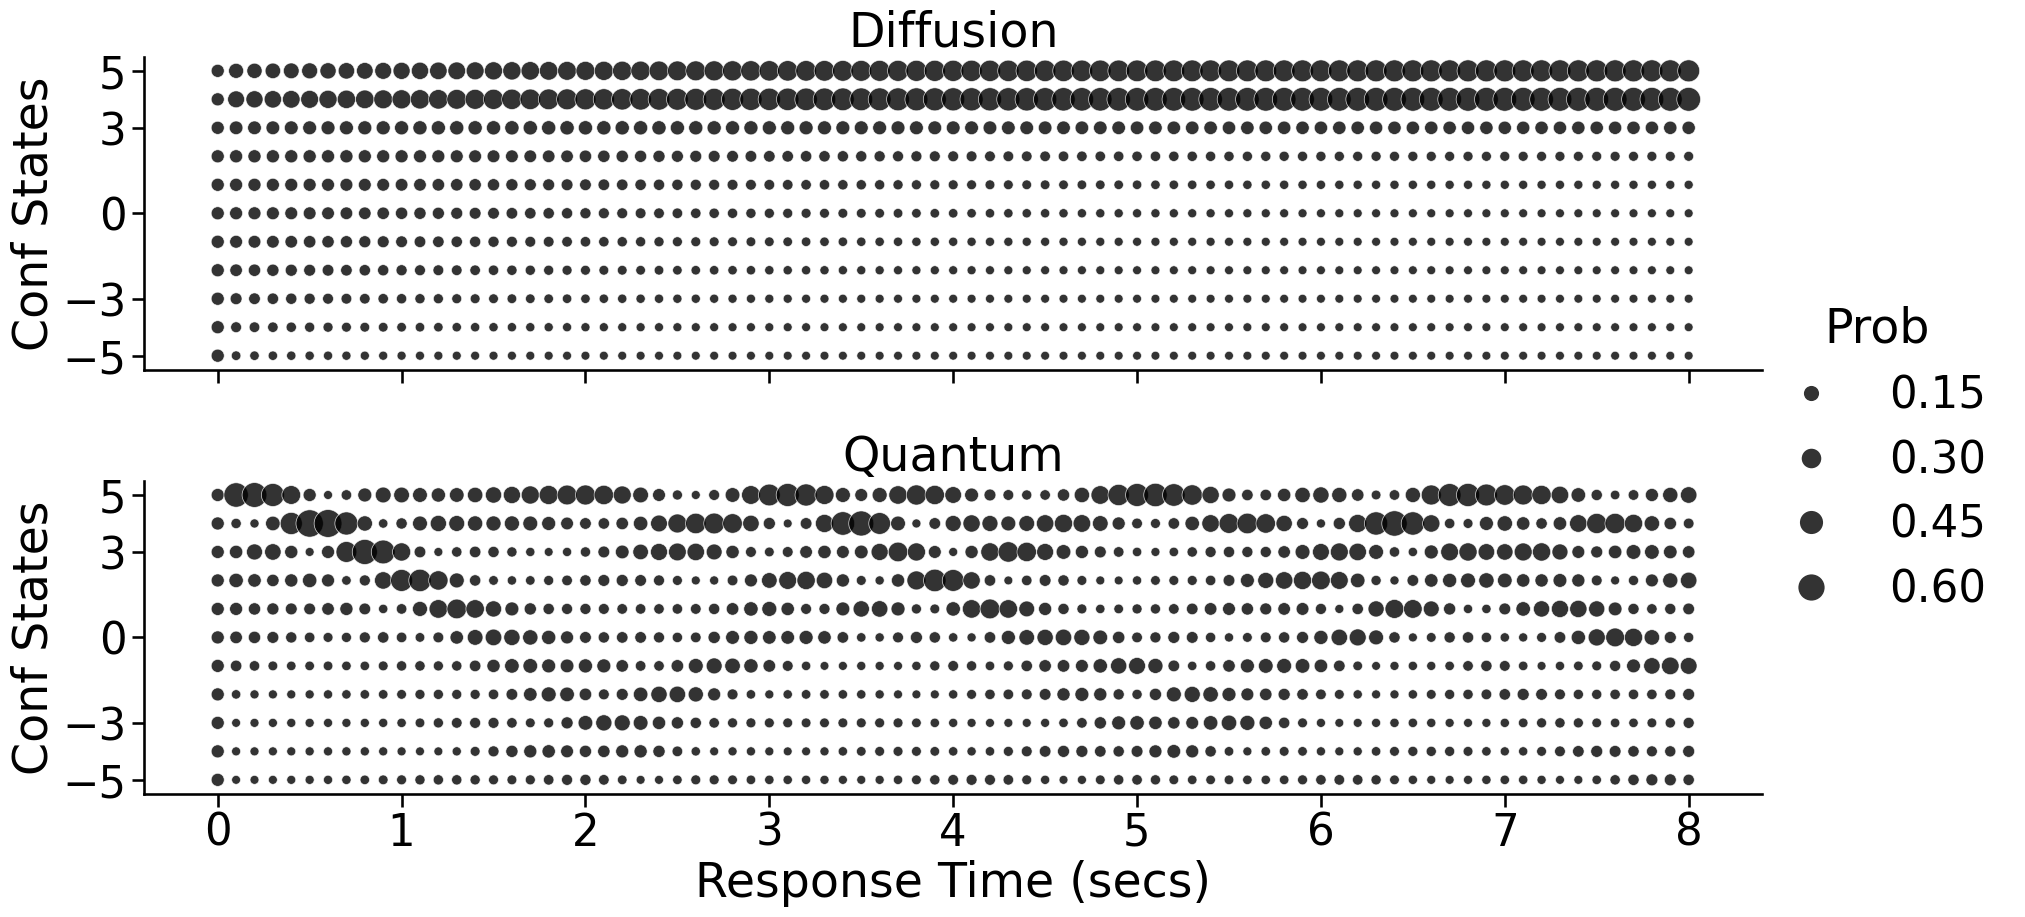

In [19]:
with sns.plotting_context("talk",font_scale=1.9):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 8 and prior == 'Uniform'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.7, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    #f.set(ylim=(-5.5, 5.5))
    #f.set_yticklabels(["-5","","0","","+5"]) 
    f.set(yticks=[-5,-3,0,3,5])

In [22]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
m_mu_arr, m_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 100
q_mu_arr, q_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 100


for m_mu, q_mu in zip(m_mu_arr, q_mu_arr):
    intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

        phi_markov_arr = []
        phi_quantum_arr = []
        phi_quantum_arr_r = []
        phi_quantum_arr_c = []

        phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
        phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

        #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
        #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
        #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
        #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        
        for t in np.arange(1,10/delta,delta):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
        for t in np.arange(1,10/delta,delta):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
                  
        df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=m_mu[0,0].item())])
        df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=q_mu[0,0].item())])
        
        

In [23]:
df_markov_plot1 = df_markov.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot1 = df_quantum.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot1 = df_markov_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot1 = df_quantum_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

In [24]:
df_conf_plot = pd.concat([df_markov_plot1.assign(model="Diffusion"), df_quantum_plot1.assign(model="Quantum")])
df_conf_plot= df_conf_plot.groupby(["prior", "mu", "time", "model"])["value"].apply(lambda ds: (mv_arr*ds).sum()).reset_index(name="conf_state")
df_conf_plot

,prior,mu,time,model,conf_state
0,+High,0.1,0.0,Diffusion,4.000000
1,+High,0.1,0.0,Quantum,4.000000
2,+High,0.1,0.1,Diffusion,3.365283
3,+High,0.1,0.1,Quantum,2.099000
4,+High,0.1,0.2,Diffusion,3.316216
...,...,...,...,...,...
23779,Uniform,3.0,98.8,Quantum,1.518757
23780,Uniform,3.0,98.9,Diffusion,4.500000
23781,Uniform,3.0,98.9,Quantum,1.435417
23782,Uniform,3.0,99.0,Diffusion,4.500000


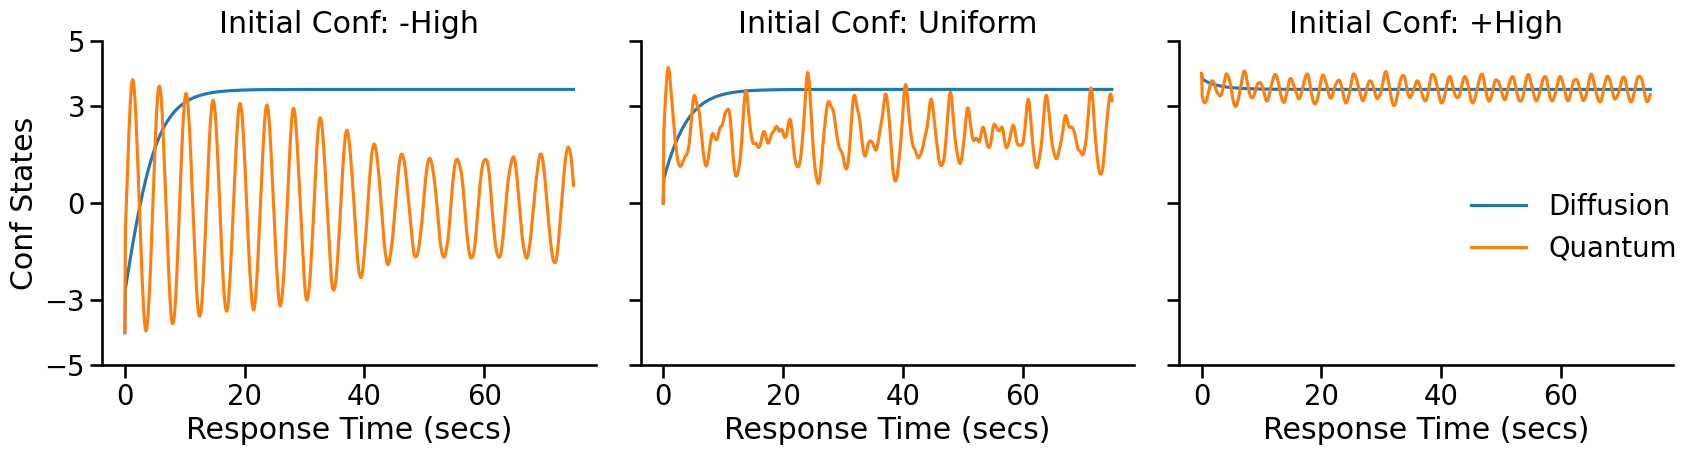

In [27]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("mu==1 and time < 75"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Uniform", "+High"]
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    plt.tight_layout()

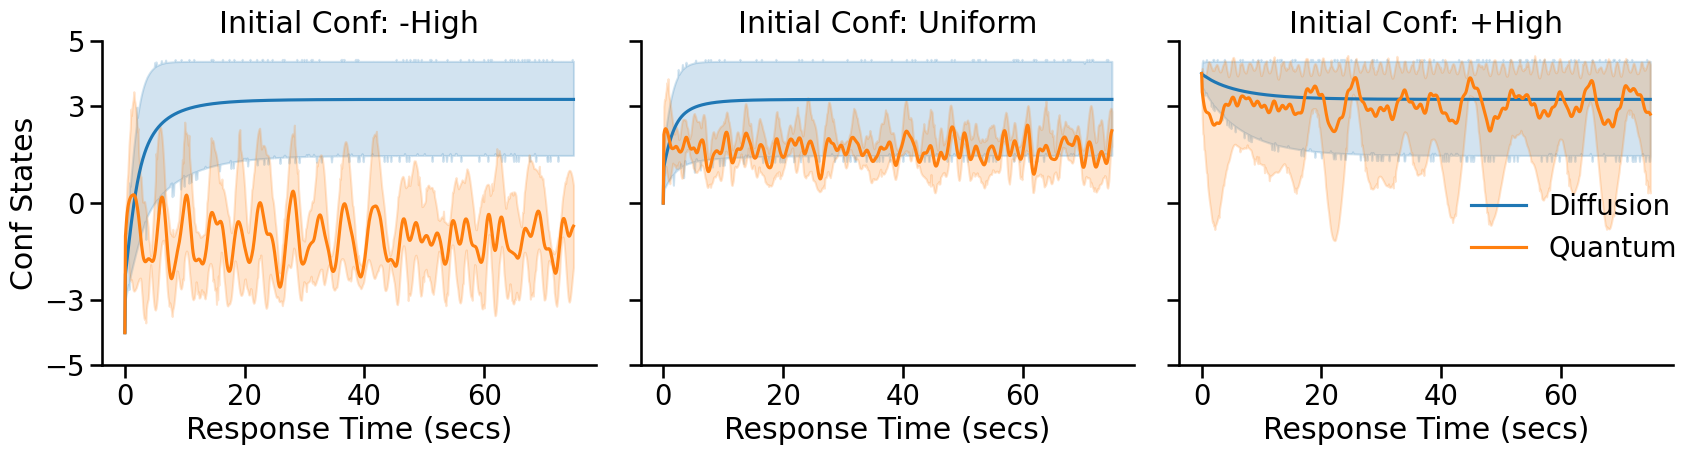

In [28]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("time < 75"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Uniform", "+High"]
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    plt.tight_layout()